# Week 01 · Digital Imaging Fundamentals

**Course:** Computer Vision (BCSE)  
**Instructor:** Bùi Huy Kiên  

---


## 🎯 Mục tiêu học tập
Sau khi hoàn thành bài này, sinh viên sẽ có thể:
- Hiểu được khái niệm về ảnh số (pixel, biểu diễn dưới dạng ma trận).
- Giải thích được các khái niệm lấy mẫu (sampling), lượng tử hóa (quantization) và độ phân giải (resolution).
- Thao tác và hiển thị ảnh bằng OpenCV.
- Quan sát được ảnh hưởng của việc giảm độ phân giải và số mức xám.



## 📘 Ôn tập lý thuyết
- **Ảnh số (Digital Image)** = ma trận 2 chiều gồm các pixel.  
- **Lấy mẫu (Sampling)** = chọn số lượng pixel để biểu diễn ảnh.  
- **Lượng tử hóa (Quantization)** = quyết định số mức cường độ sáng (mức xám) mà mỗi pixel có thể nhận.  
- **Độ phân giải (Resolution)** = được xác định bởi cả việc lấy mẫu và lượng tử hóa.  
- **Biểu diễn màu (Color Representation)** = các hệ màu như RGB, Grayscale, HSV.  


In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# For inline plots
%matplotlib inline


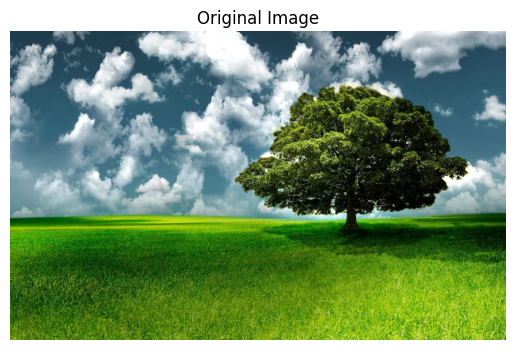

In [2]:
# Load image
img = cv2.imread("3.jpg")   # replace with any image file
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [3]:
# Show shape and a few pixel values
print("Image shape (H, W, C):", img_rgb.shape)
print("Pixel at (50,50):", img_rgb[50,50])  # R,G,B values

Image shape (H, W, C): (634, 1019, 3)
Pixel at (50,50): [155 172 180]


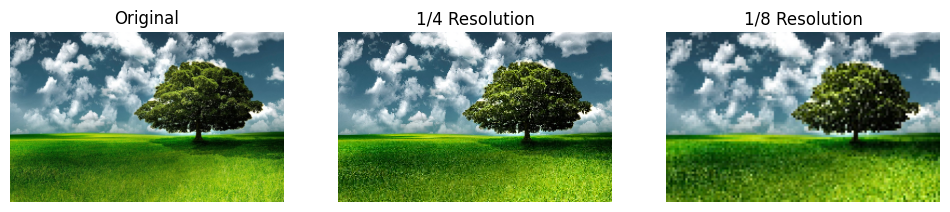

In [4]:
def downsample(img, factor):
    h, w = img.shape[:2]
    return cv2.resize(img, (w//factor, h//factor), interpolation=cv2.INTER_NEAREST)

fig, axes = plt.subplots(1,3, figsize=(12,4))
axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(downsample(img_rgb, 4))
axes[1].set_title("1/4 Resolution")
axes[1].axis("off")

axes[2].imshow(downsample(img_rgb, 8))
axes[2].set_title("1/8 Resolution")
axes[2].axis("off")
plt.show()


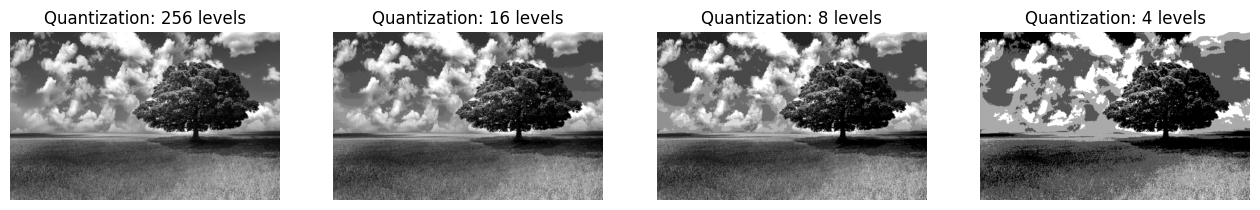

In [5]:
def quantize_gray(img, levels):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    max_val = 256
    step = max_val // levels
    return (gray // step) * step

levels = [256, 16, 8, 4]
fig, axes = plt.subplots(1, len(levels), figsize=(16,4))
for i, l in enumerate(levels):
    q = quantize_gray(img_rgb, l)
    axes[i].imshow(q, cmap="gray")
    axes[i].set_title(f"Quantization: {l} levels")
    axes[i].axis("off")
plt.show()


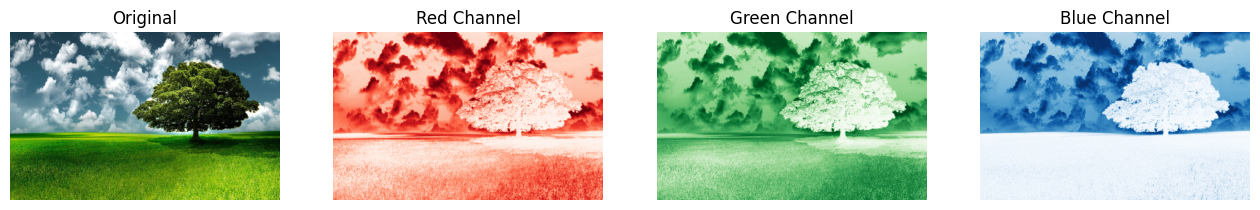

In [6]:
r, g, b = cv2.split(img_rgb)

fig, axes = plt.subplots(1,4, figsize=(16,4))
axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(r, cmap="Reds")
axes[1].set_title("Red Channel")
axes[1].axis("off")

axes[2].imshow(g, cmap="Greens")
axes[2].set_title("Green Channel")
axes[2].axis("off")

axes[3].imshow(b, cmap="Blues")
axes[3].set_title("Blue Channel")
axes[3].axis("off")
plt.show()


## 📝 Exercises (en)
1. Load another image (your own photo or dataset sample) and repeat the experiments.
2. Try different sampling factors (e.g., 2, 4, 10) and observe the difference.
3. Quantize the image to 2 gray levels (black/white). Compare with simple thresholding.
4. Explain how sampling and quantization affect image quality.
5. (Optional) Convert the image to HSV and display Hue, Saturation, and Value channels.

## 📝 Bài tập (vi)
1. Tải một ảnh khác (ảnh cá nhân hoặc ảnh từ dataset) và lặp lại các thí nghiệm.  
2. Thử các hệ số lấy mẫu khác nhau (ví dụ: 2, 4, 10) và quan sát sự khác biệt.  
3. Lượng tử hóa ảnh xuống còn 2 mức xám (đen/trắng). So sánh với phương pháp ngưỡng hóa (thresholding) đơn giản.  
4. Giải thích cách việc lấy mẫu và lượng tử hóa ảnh hưởng đến chất lượng ảnh.  
5. (Tuỳ chọn) Chuyển ảnh sang hệ màu HSV và hiển thị các kênh Hue, Saturation và Value.  
